# MountainCar Discretization

This notebook builds a finite abstract MDP for `MountainCar-v0`.


In [ ]:
%load_ext autoreload
%autoreload 2

import math
import numpy as np
import random
import torch
import pandas as pd
import sys
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import itertools

# This starts from the current working directory
# and goes up until it finds the 'fogas_torch' folder or '.git'
def find_root(current_path, marker="fogas_torch"):
    current_path = Path(current_path).resolve()
    for parent in [current_path] + list(current_path.parents):
        if (parent / marker).exists():
            return parent
    return current_path

PROJECT_ROOT = find_root(Path.cwd())
print(f"Project root found at: {PROJECT_ROOT}")
DATASET_PATH = PROJECT_ROOT / "datasets" / "mountaincar.csv"

# Add project root to sys.path so we can import local packages
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from fogas_torch import LinearMDP, PolicySolver, EnvDataCollector
from fogas_torch.algorithm import (
    FOGASSolverVectorized,
    FOGASOracleSolverVectorized,
    FOGASHyperOptimizer,
    FOGASEvaluator,
    FOGASDataset,
)
from fogas_torch.dataset_collection.dataset_analyzer import DatasetAnalyzer
from fogas_torch.fqi.fqi_solver import FQISolver
from fogas_torch.fqi.fqi_evaluator import FQIEvaluator

seed = 44
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Project root found at: /shared/home/mauro.diaz/work/FOGAS
Using device: cuda


## Discretization design

MountainCar observations are `(position, velocity)`.

State grid:
- `position`: 36 bins on `[-1.2, 0.6]`
- `velocity`: 28 bins on `[-0.07, 0.07]`

This gives `36 * 28 = 1008` non-terminal abstract states.

Action space:
- `0`: push left
- `1`: no push
- `2`: push right

The environment already has an exact **discrete** action space, so unlike the continuous version there is no action discretization step.

We add one absorbing abstract state:
- `GOAL_STATE_ID`: successful termination (`position >= 0.5` and `velocity >= goal_velocity`)

Total abstract states: `1009`.

As with the continuous notebook, we do not infer `P` and `r` from data. Gymnasium already gives the exact transition and reward equations, so we build the abstract model directly from them.

We also do **not** add a separate time-limit state. The `200`-step truncation is a wrapper-level constraint that depends on elapsed time, not only on the observation, so it is recorded in the offline dataset but excluded from the Markov abstraction itself.


In [ ]:
ENV_ID = "MountainCar-v0"
GAMMA = 0.9
GOAL_POSITION = 0.5
GOAL_VELOCITY = 0.0
MIN_POSITION = -1.2
MAX_POSITION = 0.6
MAX_SPEED = 0.07
FORCE = 0.001
GRAVITY_COEFF = 0.0025
TIME_LIMIT = 200

STATE_BINS = np.array([20, 20], dtype=np.int64)
OBS_LOW = np.array([MIN_POSITION, -MAX_SPEED], dtype=np.float64)
OBS_HIGH = np.array([MAX_POSITION, MAX_SPEED], dtype=np.float64)
ACTION_IDS = np.array([0, 1, 2], dtype=np.int64)
ACTION_LABELS = {0: "left", 1: "coast", 2: "right"}
ACTION_ACCELERATIONS = np.array([-1, 0, 1], dtype=np.int64)
ACTION_FORCES = ACTION_ACCELERATIONS.astype(np.float64) * FORCE
N_ACTIONS = int(len(ACTION_IDS))

CORE_STATE_COUNT = int(np.prod(STATE_BINS))
GOAL_STATE_ID = CORE_STATE_COUNT
N_STATES = CORE_STATE_COUNT + 1

states = torch.arange(N_STATES, dtype=torch.int64)
actions = torch.arange(N_ACTIONS, dtype=torch.int64)

BIN_EDGES = [
    np.linspace(lo, hi, n_bins + 1, dtype=np.float64)
    for lo, hi, n_bins in zip(OBS_LOW, OBS_HIGH, STATE_BINS)
]
BIN_CENTERS = [0.5 * (edges[:-1] + edges[1:]) for edges in BIN_EDGES]


def clip_obs(obs):
    obs = np.asarray(obs, dtype=np.float64)
    return np.clip(obs, OBS_LOW, OBS_HIGH)


def is_goal_obs(obs, goal_velocity=GOAL_VELOCITY):
    position, velocity = np.asarray(obs, dtype=np.float64)
    return bool(position >= GOAL_POSITION and velocity >= goal_velocity)


def obs_to_multi_bin(obs):
    obs = clip_obs(obs)
    multi = []
    for value, lo, hi, n_bins in zip(obs, OBS_LOW, OBS_HIGH, STATE_BINS):
        width = (hi - lo) / n_bins
        idx = int(np.floor((value - lo) / width))
        idx = min(max(idx, 0), int(n_bins) - 1)
        multi.append(idx)
    return tuple(multi)


def multi_bin_to_state_id(multi_bin):
    return int(np.ravel_multi_index(multi_bin, STATE_BINS))


def state_id_to_multi_bin(state_id):
    return tuple(np.unravel_index(int(state_id), STATE_BINS))


def obs_to_state_id(obs):
    return multi_bin_to_state_id(obs_to_multi_bin(obs))


def state_id_to_center_obs(state_id):
    state_id = int(state_id)
    if state_id == GOAL_STATE_ID:
        return np.array([np.nan, np.nan], dtype=np.float64)
    multi_bin = state_id_to_multi_bin(state_id)
    return np.array([BIN_CENTERS[d][idx] for d, idx in enumerate(multi_bin)], dtype=np.float64)


def action_id_to_label(action_id):
    return ACTION_LABELS[int(action_id)]


def action_id_to_force(action_id):
    return float(ACTION_FORCES[int(action_id)])


INITIAL_OBS_REFERENCE = np.array([-0.5, 0.0], dtype=np.float64)
INITIAL_STATE_ID = obs_to_state_id(INITIAL_OBS_REFERENCE)

env = gym.make(ENV_ID, goal_velocity=GOAL_VELOCITY)
sampled_initial_obs, _ = env.reset(seed=seed)
env.close()

print(f"Sampled initial observation: {sampled_initial_obs}")
print(f"Reference initial observation: {INITIAL_OBS_REFERENCE}")
print(f"Reference initial abstract state id: {INITIAL_STATE_ID}")
print(f"Non-terminal abstract states: {CORE_STATE_COUNT}")
print(f"Total abstract states: {N_STATES}")
print(f"Discrete action ids: {ACTION_IDS}")
print(f"Action labels: {[ACTION_LABELS[int(a)] for a in ACTION_IDS]}")


Sampled initial observation: [-0.5754869  0.       ]
Reference initial observation: [-0.5  0. ]
Reference initial abstract state id: 150
Non-terminal abstract states: 400
Total abstract states: 401
Discrete action ids: [0 1 2]
Action labels: ['left', 'coast', 'right']


## Plotting methods

In [50]:
def plot_policy(
    pi,
    N_STATES,
    N_ACTIONS,
    STATE_BINS,
    BIN_CENTERS,
    BIN_EDGES,
    state_id_to_multi_bin,
    CORE_STATE_COUNT=None,
    title="Greedy Policy in MountainCar Phase Space",
    action_labels=("left", "coast", "right"),
    colors=("#440154", "#21918c", "#fde725"),
    figsize=(12, 7),
    draw_boundaries=True,
    ax=None,
):
    """
    Plot the greedy policy derived from a given policy matrix.

    Parameters
    ----------
    pi : torch.Tensor
        Policy tensor of shape (N_STATES * N_ACTIONS,) or (N_STATES, N_ACTIONS).
        Each row should be action logits/probabilities; argmax is taken as the greedy action.
    N_STATES : int
        Number of abstract/discretized states.
    N_ACTIONS : int
        Number of actions.
    STATE_BINS : tuple
        Shape of the spatial grid, e.g. (N_X, N_V).
    BIN_CENTERS : list of arrays
        [centers_x, centers_v] used for the contour grid.
    BIN_EDGES : list of arrays
        [edges_x, edges_v] used for pcolormesh.
    state_id_to_multi_bin : callable
        Maps a flat state index s -> (i, j) multi-index into the grid.
    CORE_STATE_COUNT : int, optional
        How many states to fill in the grid. Defaults to N_STATES.
    title : str
        Plot title.
    action_labels : sequence of str
        Labels for the colorbar ticks, one per action.
    colors : sequence of str
        Hex colors for each action class.
    figsize : tuple
        Figure size passed to plt.subplots.
    draw_boundaries : bool
        Whether to draw contour lines at action boundaries.
    ax : matplotlib Axes, optional
        If provided, draws into this Axes instead of creating a new figure.

    Returns
    -------
    fig, ax : matplotlib Figure and Axes (fig is None if an external ax was passed).
    """
    if CORE_STATE_COUNT is None:
        CORE_STATE_COUNT = int(np.prod(STATE_BINS))  # ← was N_STATES


    # --- Greedy actions ---
    pi_mat = pi.reshape(N_STATES, N_ACTIONS)
    greedy_actions = torch.argmax(pi_mat, dim=1).cpu().numpy()

    # --- Fill policy grid ---
    policy_grid = np.full(tuple(STATE_BINS), fill_value=-1, dtype=np.int64)
    for s in range(CORE_STATE_COUNT):
        i, j = state_id_to_multi_bin(s)
        policy_grid[i, j] = greedy_actions[s]

    # --- Colormap ---
    n_actions = len(action_labels)
    cmap = ListedColormap(list(colors)[:n_actions])
    norm = BoundaryNorm(
        [-0.5 + k for k in range(n_actions + 1)], cmap.N
    )

    # --- Figure / Axes ---
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = None

    X, V = np.meshgrid(BIN_CENTERS[0], BIN_CENTERS[1], indexing="ij")

    pcm = ax.pcolormesh(
        BIN_EDGES[0],
        BIN_EDGES[1],
        policy_grid.T,
        cmap=cmap,
        norm=norm,
        shading="flat",
    )

    if draw_boundaries:
        for a in range(n_actions - 1):
            ax.contour(
                X, V,
                (policy_grid == a).astype(float),
                levels=[0.5],
                linewidths=1.2,
            )

    ax.set_xlabel("Position")
    ax.set_ylabel("Velocity")
    ax.set_title(title)

    target_fig = fig if own_fig else ax.get_figure()
    cbar = target_fig.colorbar(pcm, ax=ax, ticks=list(range(n_actions)))
    cbar.ax.set_yticklabels(list(action_labels))

    if own_fig:
        plt.tight_layout()
        plt.show()

    return fig, ax


In [51]:
def evaluate_and_save_gif(policy, filename, env_id=ENV_ID, fps=30):
    """
    Evaluates a policy in the environment and saves a GIF of the result.
    
    Args:
        policy: Tensor of shape (N_STATES, N_ACTIONS) containing action weights/probs.
        filename: String name for the output GIF (e.g., 'mountain_car_result.gif').
        env_id: The gymnasium environment ID.
        fps: Frames per second for the output GIF.
    """
    print(f"Starting simulation for {filename}...")
    
    # Check if policy is 2D (N_STATES, N_ACTIONS) or a 1D vector of greedy actions
    is_distribution = (len(policy.shape) == 2)
    
    test_env = gym.make(env_id, render_mode="rgb_array")
    obs, info = test_env.reset()
    
    total_reward = 0.0
    steps = 0
    done = False
    frames = []

    # Capture initial frame
    frames.append(test_env.render())

    while not done:
        # 1. Discretize the observation
        state_id = obs_to_state_id(obs)
        
        # 2. Extract the action
        if is_distribution:
            # Policy is a distribution (like mdp.pi_star)
            action = int(torch.argmax(policy[state_id]))
        else:
            # Policy is already a vector of greedy actions
            action = int(policy[state_id])
        
        # 3. Step environment
        obs, reward, terminated, truncated, info = test_env.step(action)
        
        # 4. Record frame
        frames.append(test_env.render())
        
        total_reward += reward
        steps += 1
        done = terminated or truncated

    test_env.close()

    # Results summary
    status = "Success! Reached goal" if terminated else "Failed (Time Limit)"
    print(f"{status} in {steps} steps. Total Reward: {total_reward}")

    # Save to GIF
    print(f"Saving GIF to {filename}...")
    imageio.mimsave(filename, frames, fps=fps)
    print("Done!")

## Exact MountainCar dynamics

We use the exact Gymnasium dynamics and reward function instead of estimating them from data.

Official references:
- Docs: https://gymnasium.farama.org/main/environments/classic_control/mountain_car/
- Source: https://github.com/Farama-Foundation/Gymnasium/blob/main/gymnasium/envs/classic_control/mountain_car.py

For default `goal_velocity = 0.0`, Gymnasium uses:
- `velocity_{t+1} = clip(velocity_t + (action - 1) * 0.001 - 0.0025 * cos(3 * position_t), -0.07, 0.07)`
- `position_{t+1} = clip(position_t + velocity_{t+1}, -1.2, 0.6)`
- left-wall collisions reset negative velocity to `0.0`
- reward is always `-1.0` on non-absorbing transitions


In [52]:
def mountaincar_step(obs, action_id, goal_velocity=GOAL_VELOCITY):
    position, velocity = np.asarray(obs, dtype=np.float64)
    action_id = int(action_id)
    if action_id not in (0, 1, 2):
        raise ValueError(f"MountainCar action must be 0, 1, or 2. Got {action_id}.")

    velocity = velocity + (action_id - 1) * FORCE - GRAVITY_COEFF * math.cos(3.0 * position)
    velocity = float(np.clip(velocity, -MAX_SPEED, MAX_SPEED))

    position = position + velocity
    position = float(np.clip(position, MIN_POSITION, MAX_POSITION))

    if position == MIN_POSITION and velocity < 0.0:
        velocity = 0.0

    terminated = bool(position >= GOAL_POSITION and velocity >= goal_velocity)
    reward = -1.0

    next_obs = np.array([position, velocity], dtype=np.float64)
    return next_obs, float(reward), terminated

In [53]:
# Initialize matrices
# P[s, a, s'] represents the probability of transitioning to state s' given state s and action a
P = np.zeros((N_STATES, N_ACTIONS, N_STATES), dtype=np.float64)
# r[s, a] represents the expected reward for taking action a in state s
r = np.zeros((N_STATES, N_ACTIONS), dtype=np.float64)

for s in range(N_STATES):
    for a in ACTION_IDS:
        # Handle the absorbing Goal State
        if s == GOAL_STATE_ID:
            # If we are already at the goal, we stay there forever with zero reward
            P[s, a, s] = 1.0
            r[s, a] = 0.0
            continue
            
        # 1. Get the representative continuous observation for state s
        obs = state_id_to_center_obs(s)
        
        # 2. Simulate the environment dynamics
        next_obs, reward, terminated = mountaincar_step(obs, a)
        
        # 3. Determine the resulting discrete state
        if terminated:
            next_s = GOAL_STATE_ID
        else:
            next_s = obs_to_state_id(next_obs)
            
        # 4. Update the matrices (Transitions are deterministic in this discretization)
        P[s, a, next_s] = 1.0
        r[s, a] = reward

print(f"Transition matrix P shape: {P.shape}")
print(f"Reward matrix r shape: {r.shape}")

# Quick sanity check: Every state-action pair should have transition probabilities summing to 1.0
assert np.allclose(P.sum(axis=2), 1.0), "Transition probabilities don't sum to 1!"

Transition matrix P shape: (401, 3, 401)
Reward matrix r shape: (401, 3)


## MDP construction

In [ ]:
# 1. Define a coarser grid for RBF centers (10x10 = 100 centers)
RBF_BINS = np.array([10, 10], dtype=np.int64)

# Generate the centers linearly spaced across the state space
RBF_EDGES = [
    np.linspace(lo, hi, n_bins + 1, dtype=np.float64)
    for lo, hi, n_bins in zip(OBS_LOW, OBS_HIGH, RBF_BINS)
]
RBF_GRID_CENTERS = [0.5 * (edges[:-1] + edges[1:]) for edges in RBF_EDGES]

# Create the actual coordinates for the 100 centers
RBF_CENTERS = np.array(list(itertools.product(*RBF_GRID_CENTERS)), dtype=np.float64)
K_CENTERS = len(RBF_CENTERS)

# 2. Set the bandwidth (sigma) based on the distance between these new centers
width_position = (MAX_POSITION - MIN_POSITION) / RBF_BINS[0]
width_velocity = (MAX_SPEED - (-MAX_SPEED)) / RBF_BINS[1]

# Scaling factor for the variance (1.0 means kernels span roughly the distance to the next center)
VARIANCE_SCALE = 1.0 
SIGMA_SQUARED = np.array([(width_position)**2, (width_velocity)**2], dtype=np.float64) * VARIANCE_SCALE

# 3. Total feature dimension d = k * |A|
D_RBF = K_CENTERS * N_ACTIONS

def phi_rbf(state_id, action_id):
    """
    Computes the block-diagonal RBF feature vector for a given state and action.
    Maps to R^d where d = K_CENTERS * N_ACTIONS.
    """
    # Get the continuous observation for the discrete state
    obs = state_id_to_center_obs(state_id)
    
    # Handle the absorbing Goal State (return a zero vector)
    if np.isnan(obs).any():
        return torch.zeros(D_RBF, dtype=torch.float64)
    
    # Compute squared distance to all 100 centers, normalized by sigma squared
    diff_sq = (RBF_CENTERS - obs) ** 2
    
    # Apply the RBF exponential: exp(-0.5 * sum( (x - c)^2 / sigma^2 ))
    f_x = np.exp(-0.5 * np.sum(diff_sq / SIGMA_SQUARED, axis=1))
    
    # Block diagonalize based on the chosen action
    feat = np.zeros(D_RBF, dtype=np.float64)
    start_idx = int(action_id) * K_CENTERS
    end_idx = start_idx + K_CENTERS
    feat[start_idx:end_idx] = f_x
    
    return torch.from_numpy(feat)

print(f"Number of RBF centers (k): {K_CENTERS}")
print(f"Total feature dimension (d): {D_RBF}")

Number of RBF centers (k): 100
Total feature dimension (d): 300


In [43]:
# Tabular one-hot features over state-action pairs
D = N_STATES * N_ACTIONS

def phi(state_id, action_id):
    feat = torch.zeros(D, dtype=torch.float64)
    idx = int(state_id) * N_ACTIONS + int(action_id)
    feat[idx] = 1.0
    return feat

# Since phi is one-hot, omega is just the flattened reward table
omega = torch.from_numpy(r.reshape(-1)).to(dtype=torch.float64)

def reward_fn(s_id, a_id):
    # If it's the goal state, return 0
    if s_id == GOAL_STATE_ID:
        return 0.0
    
    # Otherwise, return the reward from your step function
    obs = state_id_to_center_obs(s_id)
    _, reward, _ = mountaincar_step(obs, a_id)
    return float(reward)

# PolicySolver expects P with shape (N_STATES * N_ACTIONS, N_STATES)
P_flat = torch.from_numpy(P.reshape(N_STATES * N_ACTIONS, N_STATES)).to(dtype=torch.float64)

mdp = PolicySolver(
    states=states,
    actions=actions,
    phi=phi_rbf,
    reward_fn=reward_fn,
    gamma=GAMMA,
    x0=INITIAL_STATE_ID,
    P=P_flat,
    terminal_states={GOAL_STATE_ID},
)

print("MDP built.")
print("Phi dimension:", mdp.d)
print("Optimal return:", mdp.optimal_policy_return())

pi_star = mdp.pi_star.reshape(N_STATES, N_ACTIONS)
greedy_actions = torch.argmax(pi_star, dim=1)

print("Initial state greedy action:", action_id_to_label(greedy_actions[INITIAL_STATE_ID].item()))


MDP built.
Phi dimension: 300
Optimal return: -0.6151039211065154
Initial state greedy action: right


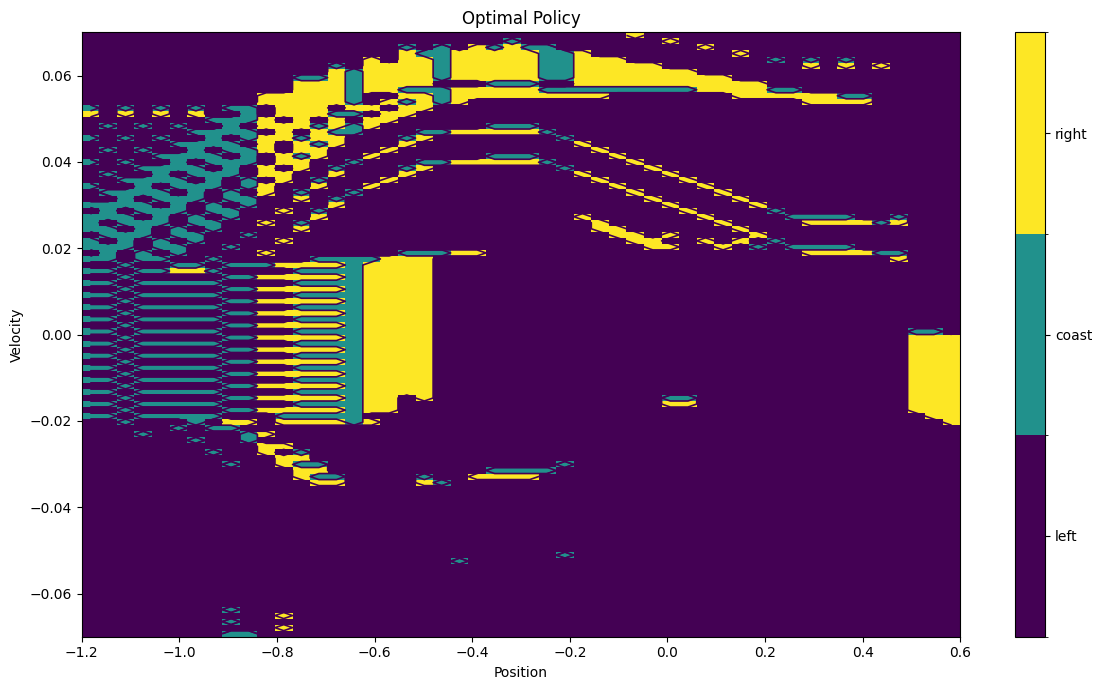

(<Figure size 1200x700 with 2 Axes>,
 <Axes: title={'center': 'Optimal Policy'}, xlabel='Position', ylabel='Velocity'>)

In [44]:
plot_policy(mdp.pi_star, N_STATES, N_ACTIONS, STATE_BINS, BIN_CENTERS, BIN_EDGES,
            state_id_to_multi_bin,
            CORE_STATE_COUNT=int(np.prod(STATE_BINS)),
            title="Optimal Policy")

In [48]:
evaluate_and_save_gif(mdp.pi_star, 'mountain_car_optimal.gif')

Starting simulation for mountain_car_optimal.gif...


ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1334:(snd_func_refer) error evaluating name
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5701:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2664:(snd_pcm_open_noupdate) Unknown PCM default


Failed (Time Limit) in 200 steps. Total Reward: -200.0
Saving GIF to mountain_car_optimal.gif...
Done!


In [ ]:
import gymnasium as gym
import numpy as np
import torch
import matplotlib.pyplot as plt

def run_q_learning(
    episodes=5000,
    alpha=0.9,
    gamma=0.9,
    epsilon_start=1.0,
    render=False,
    seed=44,
):
    env = gym.make(
        ENV_ID,
        goal_velocity=GOAL_VELOCITY,
        render_mode="human" if render else None,
    )

    rng = np.random.default_rng(seed)
    q = np.zeros((N_STATES, N_ACTIONS), dtype=np.float64)

    rewards_per_episode = np.zeros(episodes, dtype=np.float64)

    epsilon = epsilon_start
    epsilon_decay_rate = 2 / episodes

    for ep in range(episodes):
        obs, _ = env.reset(seed=seed + ep)
        s = obs_to_state_id(obs)

        terminated = False
        ep_reward = 0.0

        while (not terminated) and (ep_reward > -1000):
            if rng.random() < epsilon:
                a = env.action_space.sample()
            else:
                a = int(np.argmax(q[s]))

            next_obs, reward, terminated, truncated, _ = env.step(a)

            if terminated:
                next_s = GOAL_STATE_ID
            else:
                next_s = obs_to_state_id(next_obs)

            q[s, a] = q[s, a] + alpha * (
                reward + gamma * np.max(q[next_s]) - q[s, a]
            )

            s = next_s
            ep_reward += reward

            if truncated:
                break

        epsilon = max(epsilon - epsilon_decay_rate, 0.0)
        rewards_per_episode[ep] = ep_reward

    env.close()

    q_torch = torch.from_numpy(q).to(dtype=torch.float64)
    greedy_actions = torch.argmax(q_torch, dim=1)

    mean_rewards = np.array([
        rewards_per_episode[max(0, t - 99): t + 1].mean()
        for t in range(episodes)
    ])

    plt.figure(figsize=(8, 4))
    plt.plot(mean_rewards)
    plt.xlabel("Episode")
    plt.ylabel("Mean reward (last 100)")
    plt.title("Q-learning on discretized MountainCar")
    plt.show()

    print("Initial state greedy action:", action_id_to_label(greedy_actions[INITIAL_STATE_ID].item()))
    print("Q(initial state):", q_torch[INITIAL_STATE_ID])

    return q_torch, greedy_actions, rewards_per_episode


## Dataset Collection

In [16]:
# ── Collector: mix x0 starts (30%) with random valid starts (70%) ────────────
collector = EnvDataCollector(
    mdp=mdp,
    max_steps=500,
    terminal_states={GOAL_STATE_ID},
    reset_probs={"x0": 0.5, "random": 0.5},
    seed=42,
)

# ── Policy mix: 70% epsilon-greedy (optimal + exploration), 30% pure random ──
pi_matrix = mdp.pi_star.reshape(N_STATES, N_ACTIONS)   # shape (N, A)

df = collector.collect_mixed_dataset(
    policies=[
        (pi_matrix, 0.2),   # epsilon-greedy: 80% optimal, 20% random
        "random",           # pure random
    ],
    proportions=[0.7, 0.3],
    n_steps=50_000,
    episode_based=True,     # switch policy at episode boundaries (cleaner episodes)
    save_path=str(DATASET_PATH),
    verbose=True,
)

df.head()


  MIXED DATASET COLLECTION SUMMARY (TORCH)
Total transitions: 50000
Total episodes: 130
Mode: Episode-based

Policy Distribution:
  Policy 0: 28460 steps (56.9%) | Target: 70.0% | Episodes: 81
  Policy 1: 21540 steps (43.1%) | Target: 30.0% | Episodes: 50

✅ Mixed dataset saved to: /shared/home/mauro.diaz/work/FOGAS/datasets/mountaincar.csv


,episode,step,state,action,reward,next_state,policy_id
0,0,0,51,0,-1.0,2,1
1,0,1,2,2,-1.0,25,1
2,0,2,25,1,-1.0,26,1
3,0,3,26,1,-1.0,27,1
4,0,4,27,1,-1.0,28,1


Dataset Analysis Summary
Source: /shared/home/mauro.diaz/work/FOGAS/datasets/mountaincar.csv
Total transitions: 50,000
Unique (state, action) pairs: 2,486
Unique states visited: 977
Unique actions taken: 3
--------------------------------------------------
Pair Frequency Statistics:
  Min count:    1
  Max count:    19,902
  Mean count:   20.11
  Std count:    424.19
  Median count: 5.0
--------------------------------------------------
Coverage Statistics:
  Total possible pairs: 3,753
  Coverage: 66.24%
  Missing pairs: 1,267

Feature Coverage Ratio Details
------------------------------
  Dataset size (n):         50000
  MDP dims (N, A, d):        (1251, 3, 3753)
  gamma:                    0.99
  beta (ridge):             0.001
  policy source:            provided

  Occupancy μ_pi summary:
    sum:                    1
    min / max:              0 / 1

  Feature occupancy λ_pi summary:
    ||λ||_2:                1
    ||λ||_1:                1
    max |λ_i|:              1

  E

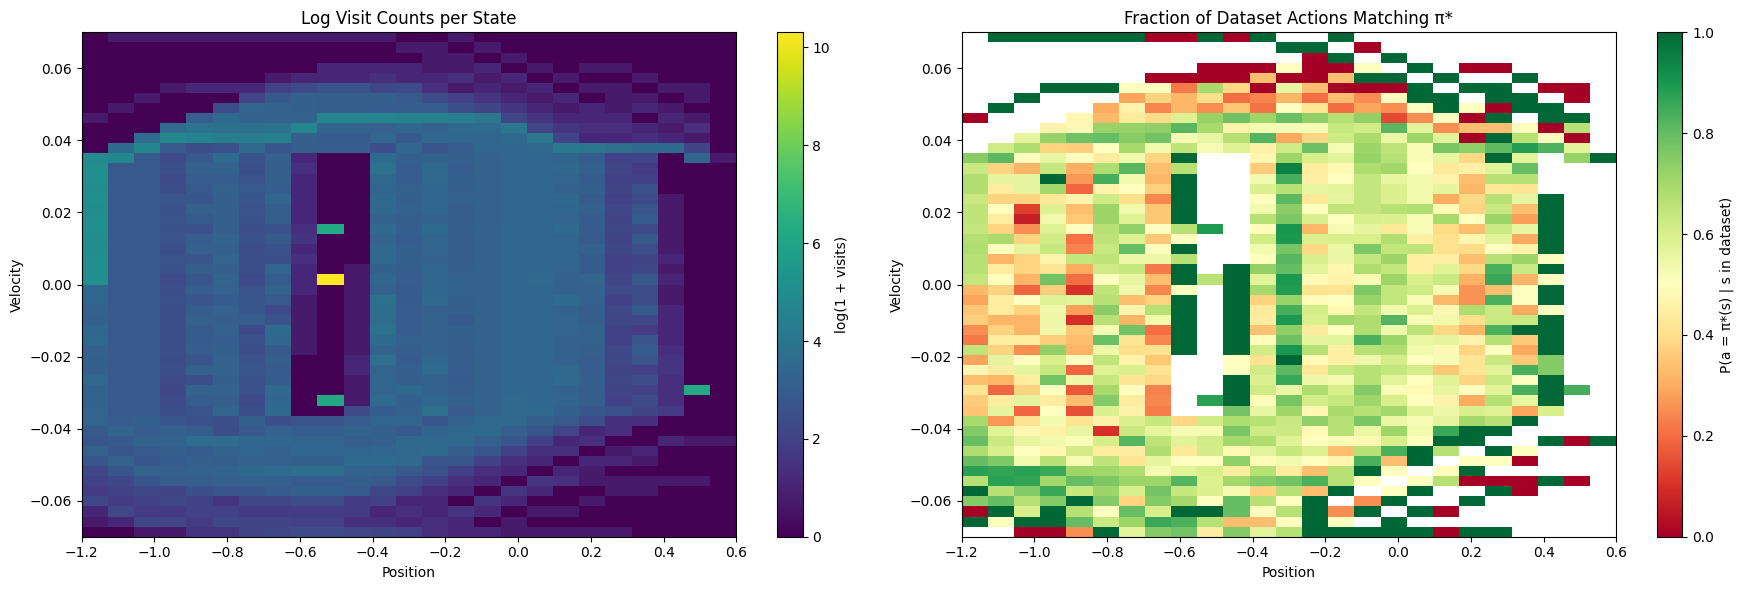

In [17]:
# ── 1. Save the dataset first (if not already done) ─────────────────────────
# df = collector.collect_mixed_dataset(..., save_path=DATASET_PATH)
# Or save manually:
df.to_csv(DATASET_PATH, columns=["state", "action", "reward", "next_state"], index=False)

# ── 2. Build the analyzer ────────────────────────────────────────────────────
analyzer = DatasetAnalyzer(DATASET_PATH)

# ── 3. Global summary ────────────────────────────────────────────────────────
analyzer.summary(n_states=N_STATES, n_actions=N_ACTIONS)

# ── 4. Feature coverage ratio w.r.t. optimal policy (the key FOGAS metric) ──
ratio = analyzer.feature_coverage_ratio(
    mdp=mdp,
    beta=1e-3,
    use_optimal_policy=True,   # uses mdp.pi_star
    verbose=True,
    return_details=False,
)
print(f"\nCoverage ratio: {ratio:.4f}")

# ── 5. State coverage in phase space ─────────────────────────────────────────
CORE_STATE_COUNT = int(np.prod(STATE_BINS))

visited_states = set(df["state"].unique())
all_states     = set(range(CORE_STATE_COUNT))
unvisited      = all_states - visited_states

print(f"\nState coverage:  {len(visited_states)}/{CORE_STATE_COUNT}  "
      f"({100*len(visited_states)/CORE_STATE_COUNT:.1f}%)")
print(f"Unvisited states: {len(unvisited)}")

# ── 6. Visited / unvisited map in phase space ─────────────────────────────────
visit_count_grid  = np.zeros(tuple(STATE_BINS), dtype=np.int64)
optimal_match_grid = np.full(tuple(STATE_BINS), fill_value=np.nan)

greedy_actions = torch.argmax(mdp.pi_star.reshape(N_STATES, N_ACTIONS), dim=1).cpu().numpy()

for s in all_states:
    i, j          = state_id_to_multi_bin(s)
    visit_count_grid[i, j] = analyzer.count_state(s)

for s in visited_states:
    if s >= CORE_STATE_COUNT:
        continue
    i, j = state_id_to_multi_bin(s)
    # fraction of visits in state s where dataset action == optimal action
    total = analyzer.count_state(s)
    on_policy = analyzer.count_pair(s, int(greedy_actions[s]))
    optimal_match_grid[i, j] = on_policy / total if total > 0 else np.nan

# Plot 1 — visit counts (log scale)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

im0 = axes[0].pcolormesh(
    BIN_EDGES[0], BIN_EDGES[1],
    np.log1p(visit_count_grid).T,
    cmap="viridis", shading="flat",
)
axes[0].set_title("Log Visit Counts per State")
axes[0].set_xlabel("Position"); axes[0].set_ylabel("Velocity")
fig.colorbar(im0, ax=axes[0], label="log(1 + visits)")

# Plot 2 — fraction of optimal action taken per visited state
im1 = axes[1].pcolormesh(
    BIN_EDGES[0], BIN_EDGES[1],
    optimal_match_grid.T,
    cmap="RdYlGn", shading="flat", vmin=0, vmax=1,
)
axes[1].set_title("Fraction of Dataset Actions Matching π*")
axes[1].set_xlabel("Position"); axes[1].set_ylabel("Velocity")
fig.colorbar(im1, ax=axes[1], label="P(a = π*(s) | s in dataset)")

plt.tight_layout()
plt.show()


In [27]:
# 1. Initialize the Vectorized Solver
# Note: Ensure mdp is already defined (as seen in cell 13 of your notebook)
solver = FOGASSolverVectorized(
    mdp=mdp,
    csv_path=str(DATASET_PATH),
    device=device,
    beta=1e-3,
    seed=seed
)

# 2. Initialize the Evaluator
evaluator = FOGASEvaluator(solver)

# 3. Initialize the Optimizer using "reward" as the metric
# 'reward' in FOGASEvaluator returns the negative expected return (minimization)
optimizer = FOGASHyperOptimizer(
    solver=solver,
    metric_callable=evaluator.get_metric("reward"), 
    seed=seed
)

[FOGASSolverVectorized] omega estimated via regression (beta_omega=1.00e-03, n=50000)


In [28]:
# 1. Run the solver with your specific parameters
solver.run(
    alpha=0.0001, 
    eta=0.00002, 
    rho=0.5, 
    tqdm_print=True, 
    T=50000
)

# 2. Get and display the final reward using the evaluator
reward = evaluator.final_reward()
print(f"\nOptimization Finished.")
print(f"Final Scalar Reward: {reward}")

# 3. Alternatively, for a more detailed comparison against the optimal:
evaluator.compare_final_rewards()

FOGAS: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 50000/50000 [01:13<00:00, 679.77it/s]


Optimization Finished.
Final Scalar Reward: 1.0

========== FINAL REWARD COMPARISON ==========

J*(π*)   = -1.000000
J(π_FOGAS) = -1.000000
Gap (J* − J) = 0.000000e+00




In [30]:
# This prints state-wise Q-values and calculates the L2 norm error
evaluator.compare_value_functions(print_each=True) # Set to True to see all states


========== VALUE FUNCTION COMPARISON ==========

State-wise V comparison:
State 0: V*(x) = -31.055091 | V^π(x) = -35.194569 | Δ = -4.139478e+00
State 1: V*(x) = -31.055091 | V^π(x) = -35.194569 | Δ = -4.139478e+00
State 2: V*(x) = -31.055091 | V^π(x) = -35.194569 | Δ = -4.139478e+00
State 3: V*(x) = -31.055091 | V^π(x) = -35.194569 | Δ = -4.139478e+00
State 4: V*(x) = -31.055091 | V^π(x) = -35.194569 | Δ = -4.139478e+00
State 5: V*(x) = -31.055091 | V^π(x) = -35.194569 | Δ = -4.139478e+00
State 6: V*(x) = -31.055091 | V^π(x) = -35.194569 | Δ = -4.139478e+00
State 7: V*(x) = -31.055091 | V^π(x) = -35.194569 | Δ = -4.139478e+00
State 8: V*(x) = -31.055091 | V^π(x) = -35.194569 | Δ = -4.139478e+00
State 9: V*(x) = -31.055091 | V^π(x) = -35.194569 | Δ = -4.139478e+00
State 10: V*(x) = -31.055091 | V^π(x) = -35.194569 | Δ = -4.139478e+00
State 11: V*(x) = -31.055091 | V^π(x) = -44.318708 | Δ = -1.326362e+01
State 12: V*(x) = -38.888276 | V^π(x) = -43.977610 | Δ = -5.089334e+00
State 13: V*

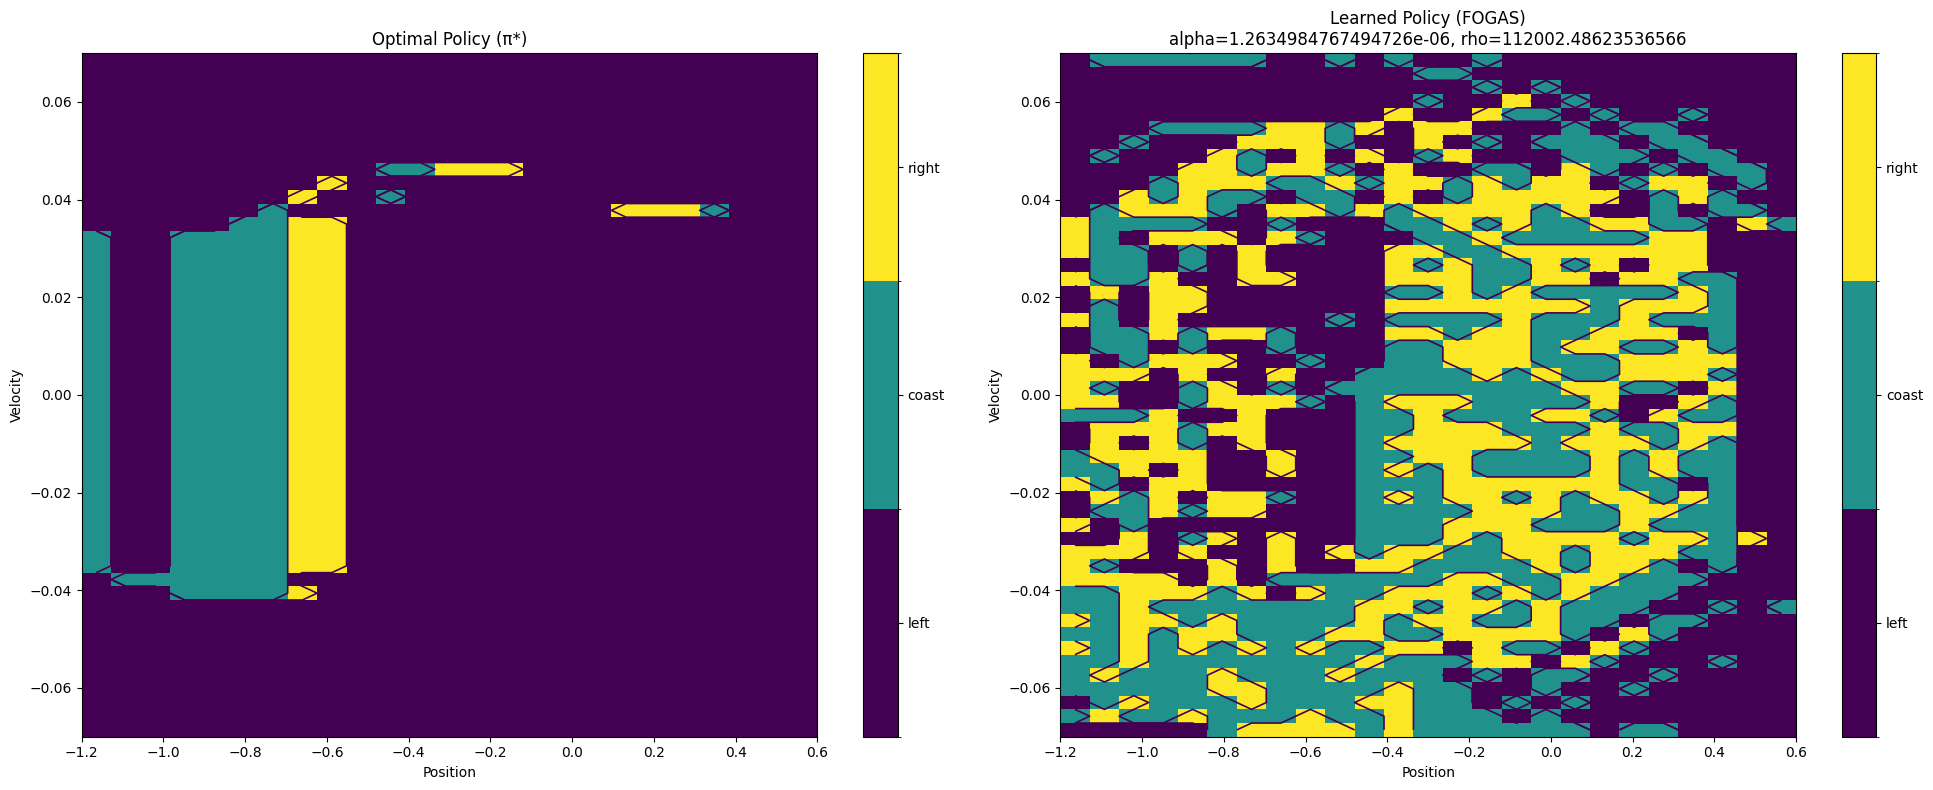

In [21]:
# 1. Create a side-by-side figure
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# 2. Plot the Optimal Policy on the first axis
plot_policy(
    mdp.pi_star, 
    N_STATES, N_ACTIONS, STATE_BINS, BIN_CENTERS, BIN_EDGES,
    state_id_to_multi_bin,
    CORE_STATE_COUNT=int(np.prod(STATE_BINS)),
    title="Optimal Policy (π*)",
    ax=axes[0]
)

# 3. Plot the FOGAS Policy on the second axis
# solver.pi contains the policy learned after your run() call
plot_policy(
    solver.pi, 
    N_STATES, N_ACTIONS, STATE_BINS, BIN_CENTERS, BIN_EDGES,
    state_id_to_multi_bin,
    CORE_STATE_COUNT=int(np.prod(STATE_BINS)),
    title=f"Learned Policy (FOGAS)\nalpha={solver.alpha}, rho={solver.rho}",
    ax=axes[1]
)

plt.tight_layout()
plt.show()

In [20]:
# 4. Run Hyperparameter Optimization (Example: tuning rho and alpha)
# This will run the solver multiple times to find the best settings
optimization_results = optimizer.optimize_fogas_hyperparameters(
    order=("rho", "alpha"),
    num_runs=1,
    print_main=True
)

# 5. Analyze Reward Approximation
# MountainCar doesn't have walls/pits, and the goal is GOAL_STATE_ID
# We set show_plot=False because the internal plotter assumes a square grid
evaluator.analyze_reward_approximation(
    goal=GOAL_STATE_ID,
    show_plot=False 
)


KeyboardInterrupt: 

## Macro Aggregation: 100x100 Fine -> 20x20 Coarse

- build a finer `100 x 100` MountainCar abstraction
- aggregate `5` repeated fine actions into one macro transition
- train a coarse `20 x 20` FOGAS solver on the macro dataset
- lift the learned macro policy back to the fine phase space


In [ ]:
MACRO_DATASET_PATH = PROJECT_ROOT / "datasets" / "mountaincar_100_to_20_macro.csv"

COARSE_STATE_BINS_MACRO = STATE_BINS.copy()
FINE_STATE_BINS_MACRO = np.array([100, 100], dtype=np.int64)

assert np.all(FINE_STATE_BINS_MACRO % COARSE_STATE_BINS_MACRO == 0), "Fine bins must be divisible by coarse bins."
MACRO_FACTOR_BINS = (FINE_STATE_BINS_MACRO // COARSE_STATE_BINS_MACRO).astype(np.int64)
assert np.all(MACRO_FACTOR_BINS == MACRO_FACTOR_BINS[0]), "This notebook section assumes the same refinement factor on both dimensions."

MACRO_ACTION_REPEAT = int(MACRO_FACTOR_BINS[0])
GAMMA_FINE_MACRO = GAMMA ** MACRO_ACTION_REPEAT
GAMMA_COARSE_MACRO = GAMMA
MACRO_STEP_PENALTY = -sum(GAMMA_FINE_MACRO ** k for k in range(MACRO_ACTION_REPEAT))

def build_edges_and_centers(state_bins):
    bin_edges = [
        np.linspace(lo, hi, int(n_bins) + 1, dtype=np.float64)
        for lo, hi, n_bins in zip(OBS_LOW, OBS_HIGH, state_bins)
    ]
    bin_centers = [0.5 * (edges[:-1] + edges[1:]) for edges in bin_edges]
    return bin_edges, bin_centers

def make_state_converters(state_bins):
    state_bins = np.asarray(state_bins, dtype=np.int64)
    bin_edges, bin_centers = build_edges_and_centers(state_bins)
    core_state_count = int(np.prod(state_bins))
    goal_state_id = core_state_count
    n_states = core_state_count + 1

    def obs_to_multi_bin_local(obs):
        obs = clip_obs(obs)
        multi = []
        for value, lo, hi, n_bins in zip(obs, OBS_LOW, OBS_HIGH, state_bins):
            width = (hi - lo) / int(n_bins)
            idx = int(np.floor((value - lo) / width))
            idx = min(max(idx, 0), int(n_bins) - 1)
            multi.append(idx)
        return tuple(multi)

    def multi_bin_to_state_id_local(multi_bin):
        return int(np.ravel_multi_index(tuple(multi_bin), tuple(state_bins)))

    def state_id_to_multi_bin_local(state_id):
        return tuple(np.unravel_index(int(state_id), tuple(state_bins)))

    def obs_to_state_id_local(obs):
        if is_goal_obs(obs):
            return goal_state_id
        return multi_bin_to_state_id_local(obs_to_multi_bin_local(obs))

    def state_id_to_center_obs_local(state_id):
        state_id = int(state_id)
        if state_id == goal_state_id:
            return np.array([np.nan, np.nan], dtype=np.float64)
        multi_bin = state_id_to_multi_bin_local(state_id)
        return np.array([bin_centers[d][idx] for d, idx in enumerate(multi_bin)], dtype=np.float64)

    return {
        "state_bins": state_bins,
        "bin_edges": bin_edges,
        "bin_centers": bin_centers,
        "core_state_count": core_state_count,
        "goal_state_id": goal_state_id,
        "n_states": n_states,
        "obs_to_multi_bin": obs_to_multi_bin_local,
        "multi_bin_to_state_id": multi_bin_to_state_id_local,
        "state_id_to_multi_bin": state_id_to_multi_bin_local,
        "obs_to_state_id": obs_to_state_id_local,
        "state_id_to_center_obs": state_id_to_center_obs_local,
    }

def make_phi_rbf_from_converter(state_id_to_center_obs_fn, goal_state_id):
    def phi_local(state_id, action_id):
        obs = state_id_to_center_obs_fn(state_id)
        if int(state_id) == int(goal_state_id) or np.isnan(obs).any():
            return torch.zeros(D_RBF, dtype=torch.float64)

        diff_sq = (RBF_CENTERS - obs) ** 2
        f_x = np.exp(-0.5 * np.sum(diff_sq / SIGMA_SQUARED, axis=1))

        feat = np.zeros(D_RBF, dtype=np.float64)
        start_idx = int(action_id) * K_CENTERS
        end_idx = start_idx + K_CENTERS
        feat[start_idx:end_idx] = f_x
        return torch.from_numpy(feat)

    return phi_local

def build_mountaincar_linear_mdp(state_bins, gamma, phi_fn, initial_obs=INITIAL_OBS_REFERENCE):
    converters = make_state_converters(state_bins)
    n_states_local = converters["n_states"]
    goal_state_id_local = converters["goal_state_id"]
    core_state_count_local = converters["core_state_count"]

    P_local = np.zeros((n_states_local, N_ACTIONS, n_states_local), dtype=np.float64)
    r_local = np.zeros((n_states_local, N_ACTIONS), dtype=np.float64)

    for s in range(n_states_local):
        for a in ACTION_IDS:
            if s == goal_state_id_local:
                P_local[s, a, s] = 1.0
                r_local[s, a] = 0.0
                continue

            obs = converters["state_id_to_center_obs"](s)
            next_obs, reward, terminated = mountaincar_step(obs, a)
            next_s = goal_state_id_local if terminated else converters["obs_to_state_id"](next_obs)
            P_local[s, a, next_s] = 1.0
            r_local[s, a] = reward

    P_flat_local = torch.from_numpy(P_local.reshape(n_states_local * N_ACTIONS, n_states_local)).to(dtype=torch.float64)
    r_flat_local = torch.from_numpy(r_local.reshape(-1)).to(dtype=torch.float64)

    def reward_fn_local(s_id, a_id):
        if int(s_id) == goal_state_id_local:
            return 0.0
        obs = converters["state_id_to_center_obs"](s_id)
        _, reward, _ = mountaincar_step(obs, a_id)
        return float(reward)

    states_local = torch.arange(n_states_local, dtype=torch.int64)
    actions_local = torch.arange(N_ACTIONS, dtype=torch.int64)
    x0_local = converters["obs_to_state_id"](initial_obs)

    mdp_local = LinearMDP(
        states=states_local,
        actions=actions_local,
        phi=phi_fn,
        reward_fn=reward_fn_local,
        gamma=gamma,
        x0=x0_local,
        P=P_flat_local,
    )
    mdp_local.r = r_flat_local

    return mdp_local, converters

def macro_reward_fn_mountaincar(s_id, a_id):
    if int(s_id) == GOAL_STATE_ID:
        return 0.0
    return float(MACRO_STEP_PENALTY)

mdp_macro_mountaincar = LinearMDP(
    states=states,
    actions=actions,
    phi=phi_rbf,
    reward_fn=macro_reward_fn_mountaincar,
    gamma=GAMMA_COARSE_MACRO,
    x0=INITIAL_STATE_ID,
    P=P_flat,
)
mdp_macro_mountaincar.r = mdp_macro_mountaincar.get_reward()

fine_converters_macro = make_state_converters(FINE_STATE_BINS_MACRO)
phi_fine_macro = make_phi_rbf_from_converter(
    fine_converters_macro["state_id_to_center_obs"],
    fine_converters_macro["goal_state_id"],
)
mdp_fine_macro, fine_converters_macro = build_mountaincar_linear_mdp(
    state_bins=FINE_STATE_BINS_MACRO,
    gamma=GAMMA_FINE_MACRO,
    phi_fn=phi_fine_macro,
)

FINE_INITIAL_STATE_ID_MACRO = fine_converters_macro["obs_to_state_id"](INITIAL_OBS_REFERENCE)
FINE_GOAL_STATE_ID_MACRO = fine_converters_macro["goal_state_id"]

print(f"Coarse bins              : {COARSE_STATE_BINS_MACRO.tolist()} ({CORE_STATE_COUNT} non-terminal states)")
print(f"Fine bins                : {FINE_STATE_BINS_MACRO.tolist()} ({fine_converters_macro['core_state_count']} non-terminal states)")
print(f"Macro repeat             : {MACRO_ACTION_REPEAT} fine steps")
print(f"Fine gamma               : {GAMMA_FINE_MACRO:.6f}")
print(f"Coarse / macro gamma     : {GAMMA_COARSE_MACRO:.6f}")
print(f"Macro dataset path       : {MACRO_DATASET_PATH}")


In [ ]:
def fine_to_coarse_state_mountaincar(state_id):
    state_id = int(state_id)
    if state_id == FINE_GOAL_STATE_ID_MACRO:
        return GOAL_STATE_ID

    fine_multi = fine_converters_macro["state_id_to_multi_bin"](state_id)
    coarse_multi = tuple(
        min(int(fine_multi[d] // MACRO_FACTOR_BINS[d]), int(COARSE_STATE_BINS_MACRO[d]) - 1)
        for d in range(len(COARSE_STATE_BINS_MACRO))
    )
    return multi_bin_to_state_id(coarse_multi)

class VelocityAwareMountainCarPolicy:
    def sample(self, state_id):
        state_id = int(state_id)
        if state_id == FINE_GOAL_STATE_ID_MACRO:
            return 1

        position, velocity = fine_converters_macro["state_id_to_center_obs"](state_id)
        if velocity < 0.0:
            return 0
        if velocity > 0.0:
            return 2
        return 2 if position < -0.4 else 0

def collect_macro_dataset_mountaincar(
    mdp_fine,
    n_macro_steps,
    gamma_fine,
    action_repeat,
    initial_state,
    terminal_state,
    fine_to_coarse_state_fn,
    policy,
    epsilon_random=0.30,
    reset_probs=None,
    seed=None,
    save_path=None,
):
    rng = random.Random(seed)
    reward_vector = mdp_fine.r if hasattr(mdp_fine, "r") else mdp_fine.get_reward()
    non_terminal_states = np.arange(int(terminal_state), dtype=np.int64)

    reset_probs = reset_probs or {"x0": 0.3, "random": 0.7}
    p_x0 = float(reset_probs.get("x0", 0.0))
    p_random = float(reset_probs.get("random", 0.0))
    total_reset = p_x0 + p_random
    if total_reset <= 0.0:
        raise ValueError("reset_probs must assign positive mass to at least one reset mode.")
    p_x0 /= total_reset

    def sample_reset_state():
        if rng.random() < p_x0:
            return int(initial_state)
        return int(rng.choice(non_terminal_states.tolist()))

    rows = []
    state = sample_reset_state()
    episode = 0
    macro_step = 0

    while len(rows) < n_macro_steps:
        coarse_state = int(fine_to_coarse_state_fn(state))
        action = int(policy.sample(state))
        if rng.random() < float(epsilon_random):
            action = rng.randrange(N_ACTIONS)

        x = int(state)
        macro_reward = 0.0

        for k in range(int(action_repeat)):
            row_idx = x * N_ACTIONS + action
            reward = float(reward_vector[row_idx].item())
            x_next = int(torch.argmax(mdp_fine.P[row_idx]).item())
            macro_reward += (float(gamma_fine) ** k) * reward
            x = x_next
            if x == int(terminal_state):
                break

        next_state = int(x)
        next_coarse_state = int(fine_to_coarse_state_fn(next_state))

        rows.append({
            "episode": episode,
            "macro_step": macro_step,
            "fine_state": int(state),
            "state": coarse_state,
            "action": action,
            "reward": macro_reward,
            "next_fine_state": next_state,
            "next_state": next_coarse_state,
        })

        state = next_state
        macro_step += 1

        if state == int(terminal_state):
            episode += 1
            macro_step = 0
            state = sample_reset_state()

    df_macro = pd.DataFrame(rows)
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        df_macro[["state", "action", "reward", "next_state"]].to_csv(save_path, index=False)
        print(f"✅ Macro dataset saved to: {save_path}")
        print(f"   Total macro transitions: {len(df_macro)}")
        print(f"   Episodes             : {episode + 1}")

    return df_macro

macro_behavior_policy = VelocityAwareMountainCarPolicy()

df_macro_mountaincar = collect_macro_dataset_mountaincar(
    mdp_fine=mdp_fine_macro,
    n_macro_steps=25_000,
    gamma_fine=GAMMA_FINE_MACRO,
    action_repeat=MACRO_ACTION_REPEAT,
    initial_state=FINE_INITIAL_STATE_ID_MACRO,
    terminal_state=FINE_GOAL_STATE_ID_MACRO,
    fine_to_coarse_state_fn=fine_to_coarse_state_mountaincar,
    policy=macro_behavior_policy,
    epsilon_random=0.30,
    reset_probs={"x0": 0.3, "random": 0.7},
    seed=seed,
    save_path=MACRO_DATASET_PATH,
)

df_macro_mountaincar.head()


In [ ]:
solver_macro_mountaincar = FOGASSolverVectorized(
    mdp=mdp_macro_mountaincar,
    csv_path=str(MACRO_DATASET_PATH),
    device=device,
    beta=1e-3,
    seed=seed,
)
evaluator_macro_mountaincar = FOGASEvaluator(solver_macro_mountaincar)

solver_macro_mountaincar.run(
    alpha=0.0001,
    eta=0.00002,
    rho=0.5,
    tqdm_print=True,
    T=20_000,
)

plot_policy(
    solver_macro_mountaincar.pi,
    N_STATES,
    N_ACTIONS,
    STATE_BINS,
    BIN_CENTERS,
    BIN_EDGES,
    state_id_to_multi_bin,
    CORE_STATE_COUNT=CORE_STATE_COUNT,
    title="Learned Macro Policy on 20x20 MountainCar",
)


In [ ]:
def lift_macro_policy_to_fine(pi_macro, fine_converters, fine_to_coarse_state_fn):
    if isinstance(pi_macro, torch.Tensor):
        pi_macro_mat = pi_macro.reshape(N_STATES, N_ACTIONS).detach().cpu().to(dtype=torch.float64)
    else:
        pi_macro_mat = torch.tensor(np.asarray(pi_macro).reshape(N_STATES, N_ACTIONS), dtype=torch.float64)

    pi_fine = torch.zeros((fine_converters["n_states"], N_ACTIONS), dtype=torch.float64)
    for s in range(fine_converters["core_state_count"]):
        coarse_s = int(fine_to_coarse_state_fn(s))
        pi_fine[s] = pi_macro_mat[coarse_s]

    pi_fine[fine_converters["goal_state_id"], 1] = 1.0
    return pi_fine

pi_macro_on_fine = lift_macro_policy_to_fine(
    solver_macro_mountaincar.pi,
    fine_converters_macro,
    fine_to_coarse_state_mountaincar,
)

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

plot_policy(
    solver_macro_mountaincar.pi,
    N_STATES,
    N_ACTIONS,
    STATE_BINS,
    BIN_CENTERS,
    BIN_EDGES,
    state_id_to_multi_bin,
    CORE_STATE_COUNT=CORE_STATE_COUNT,
    title="Macro Policy on 20x20 Coarse Grid",
    ax=axes[0],
)

plot_policy(
    pi_macro_on_fine,
    fine_converters_macro["n_states"],
    N_ACTIONS,
    fine_converters_macro["state_bins"],
    fine_converters_macro["bin_centers"],
    fine_converters_macro["bin_edges"],
    fine_converters_macro["state_id_to_multi_bin"],
    CORE_STATE_COUNT=fine_converters_macro["core_state_count"],
    title="Lifted Macro Policy on 100x100 Fine Grid",
    ax=axes[1],
)

plt.tight_layout()
plt.show()
